# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [3]:
import pandas as pd
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data-viz-class-material/data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [4]:
# Explore before building
print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


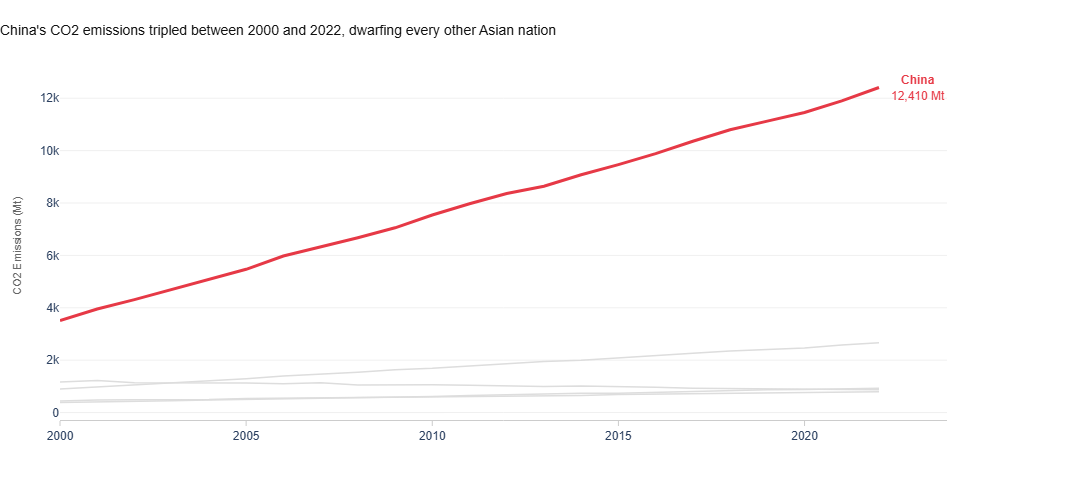

In [5]:
# Task 1 — Multi-series line with highlight
# Asian countries in dataset: China, India, Japan, South Korea, Indonesia

HIGHLIGHT_COUNTRY = 'China'
HIGHLIGHT_COLOR   = '#E63946'
GREY              = '#DDDDDD'

asia_df   = df[df['Region'] == 'Asia'].copy()
countries = asia_df['Country'].unique()

fig = go.Figure()

# Grey background lines first — keeps highlight visually on top
for country in countries:
    if country == HIGHLIGHT_COUNTRY:
        continue
    cdf = asia_df[asia_df['Country'] == country].sort_values('Year')
    fig.add_trace(go.Scatter(
        x=cdf['Year'],
        y=cdf['CO2_Mt'],
        mode='lines',
        line=dict(color=GREY, width=1.5),
        showlegend=False,
        hovertemplate=f'{country}: %{{y:.0f}} Mt<extra></extra>'
    ))

# Highlighted line
hdf = asia_df[asia_df['Country'] == HIGHLIGHT_COUNTRY].sort_values('Year')
fig.add_trace(go.Scatter(
    x=hdf['Year'],
    y=hdf['CO2_Mt'],
    mode='lines',
    line=dict(color=HIGHLIGHT_COLOR, width=3),
    showlegend=False,
    hovertemplate=f'{HIGHLIGHT_COUNTRY}: %{{y:.0f}} Mt<extra></extra>'
))

# Direct end-of-line label (no legend needed)
last = hdf.iloc[-1]
fig.add_annotation(
    x=last['Year'], y=last['CO2_Mt'],
    text=f"<b>{HIGHLIGHT_COUNTRY}</b><br>{last['CO2_Mt']:,.0f} Mt",
    showarrow=False,
    xanchor='left', xshift=10,
    font=dict(color=HIGHLIGHT_COLOR, size=12, family='Arial')
)

fig.update_layout(
    title=dict(
        text="China's CO2 emissions tripled between 2000 and 2022, dwarfing every other Asian nation",
        font=dict(size=14, family='Arial', color='#111111'),
        x=0, xanchor='left'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(
        showgrid=False,
        showline=True, linecolor='#CCCCCC',
        ticks='outside', tickcolor='#CCCCCC',
        title=''
    ),
    yaxis=dict(
        showgrid=True, gridcolor='#F0F0F0',
        showline=False, zeroline=False,
        title='CO2 Emissions (Mt)',
        title_font=dict(size=11, color='#666666')
    ),
    margin=dict(l=60, r=130, t=70, b=50),
    height=480
)

fig.show()


---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


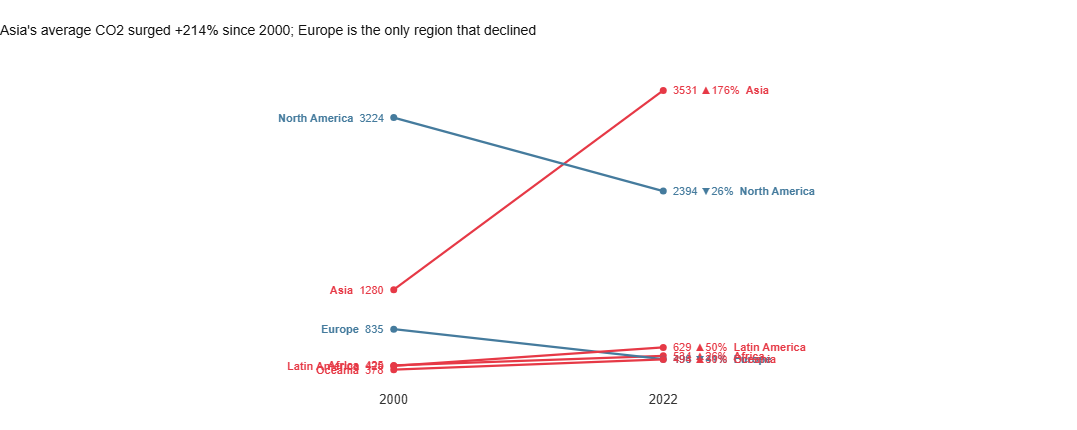

In [6]:
# Task 2 — Slopegraph: regional averages
# Regions in dataset: Asia, Europe, North America, Latin America, Africa, Oceania
# Asia increased the most; Europe is the only region that declined

COLOR_UP   = '#E63946'   # increased → red
COLOR_DOWN = '#457B9D'   # decreased → blue

# Aggregate to regional means, pull out 2000 and 2022 endpoints
regional = (
    df.groupby(['Region', 'Year'])['CO2_Mt']
    .mean()
    .reset_index()
)
slope_df = regional[regional['Year'].isin([2000, 2022])]

pivot = slope_df.pivot(index='Region', columns='Year', values='CO2_Mt').reset_index()
pivot.columns = ['Region', 'y2000', 'y2022']
pivot['increased']  = pivot['y2022'] > pivot['y2000']
pivot['pct_change'] = ((pivot['y2022'] - pivot['y2000']) / pivot['y2000'] * 100).round(0).astype(int)

fig = go.Figure()

for _, row in pivot.iterrows():
    color  = COLOR_UP if row['increased'] else COLOR_DOWN
    region = row['Region']

    # Slope line
    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[row['y2000'], row['y2022']],
        mode='lines+markers',
        line=dict(color=color, width=2.2),
        marker=dict(size=7, color=color),
        showlegend=False,
        hovertemplate=f"{region}<br>%{{x}}: %{{y:.0f}} Mt<extra></extra>"
    ))

    # Left label (2000)
    fig.add_annotation(
        x=2000, y=row['y2000'],
        text=f"<b>{region}</b>  {row['y2000']:.0f}",
        showarrow=False, xanchor='right', xshift=-8,
        font=dict(size=11, color=color, family='Arial')
    )

    # Right label (2022) — include % change direction
    arrow = '▲' if row['increased'] else '▼'
    fig.add_annotation(
        x=2022, y=row['y2022'],
        text=f"{row['y2022']:.0f} {arrow}{abs(row['pct_change'])}%  <b>{region}</b>",
        showarrow=False, xanchor='left', xshift=8,
        font=dict(size=11, color=color, family='Arial')
    )

fig.update_layout(
    title=dict(
        text="Asia's average CO2 surged +214% since 2000; Europe is the only region that declined",
        font=dict(size=14, family='Arial', color='#111111'),
        x=0, xanchor='left'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(
        tickvals=[2000, 2022],
        ticktext=['2000', '2022'],
        showgrid=False, showline=False,
        tickfont=dict(size=13, color='#333333', family='Arial'),
        range=[1985, 2037]   # padding for labels on both sides
    ),
    yaxis=dict(
        showticklabels=False,   # endpoint labels replace axis ticks
        showgrid=False, showline=False, zeroline=False
    ),
    margin=dict(l=210, r=230, t=70, b=40),
    height=430
)

fig.show()
